# AED 1: Identidade e Demografia Tecnológica
**Vertical:** Customer Analytics | **Tabelas:** `public.clientes` e `public.sessoes_dispositivos`

**Objetivo Analítico:** 
Realizar uma Análise Exploratória de Dados (AED) exaustiva na base de clientes. O fluxo seguirá do entendimento estrutural básico (`info`/`describe`), passará pelo mapeamento univariado de todas as variáveis de negócio (distribuições individuais) e culminará no cruzamento bivariado de perfil financeiro versus adoção tecnológica.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
import sys
from dotenv import load_dotenv

# Configurações de Ambiente
os.environ["PGCLIENTENCODING"] = "latin1"
load_dotenv(override=True)

# Conexão Blindada (Docker Port 5433)
db_url = URL.create(
    drivername="postgresql",
    username=os.getenv('POSTGRES_USER', 'caleb').strip(),
    password=os.getenv('POSTGRES_PASSWORD', '').strip(),
    host=os.getenv('POSTGRES_HOST', '127.0.0.1').strip(),
    port=os.getenv('POSTGRES_PORT', '5433').strip(),
    database=os.getenv('POSTGRES_DB', 'bank_twin').strip()
)

engine = create_engine(db_url)

# Configuração visual Dark Neon para Portfólio
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#111111", "figure.facecolor": "#111111", 
    "text.color": "white", "axes.labelcolor": "white", 
    "xtick.color": "white", "ytick.color": "white",
    "grid.color": "#333333"
})

# Carga dos Dados
df_clientes = pd.read_sql("SELECT * FROM clientes", engine)
df_sessoes = pd.read_sql("SELECT * FROM sessoes_dispositivos", engine)

# Feature Engineering Inicial Necessária para as distribuições
# 1. Transformar data_nascimento em 'idade'
df_clientes['idade'] = (pd.to_datetime('today') - pd.to_datetime(df_clientes['data_nascimento'])).dt.days // 365
# 2. Extrair o mês/ano de cadastro para série temporal
df_clientes['mes_cadastro'] = pd.to_datetime(df_clientes['data_cadastro']).dt.to_period('M')

print("✅ Dados carregados e features iniciais calculadas com sucesso!")

✅ Dados carregados e features iniciais calculadas com sucesso!


In [26]:
print("="*50)
print("🔍 1. ESTRUTURA E QUALIDADE: TABELA CLIENTES")
print("="*50)
display(df_clientes.info())
display(df_clientes.describe(include='all'))

print("\n" + "="*50)
print("🔍 2. ESTRUTURA E QUALIDADE: TABELA SESSÕES")
print("="*50)
display(df_sessoes.info())
display(df_sessoes.describe(include='all'))

🔍 1. ESTRUTURA E QUALIDADE: TABELA CLIENTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   cliente_id       50000 non-null  int64         
 1   nome             50000 non-null  object        
 2   cpf              50000 non-null  object        
 3   data_nascimento  50000 non-null  object        
 4   estado_civil     50000 non-null  object        
 5   uf_residencia    50000 non-null  object        
 6   renda_declarada  50000 non-null  float64       
 7   score_serasa     50000 non-null  int64         
 8   segmento         50000 non-null  object        
 9   behavior_score   50000 non-null  int64         
 10  data_cadastro    50000 non-null  datetime64[ns]
 11  idade            50000 non-null  int64         
 12  mes_cadastro     50000 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(4), obj

None

,cliente_id,nome,cpf,data_nascimento,estado_civil,uf_residencia,renda_declarada,score_serasa,segmento,behavior_score,data_cadastro,idade,mes_cadastro
count,50000.000000,50000,50000,50000,50000,50000,50000.000000,50000.000000,50000,50000.000000,50000,50000.000000,50000
unique,NaN,29806,50000,21560,4,12,NaN,NaN,3,NaN,NaN,NaN,1
top,NaN,Daniel Novais,47172138333,1979-06-09,Viúvo,DF,NaN,NaN,Classic,NaN,NaN,NaN,2026-04
freq,NaN,10,1,9,12583,4333,NaN,NaN,25026,NaN,NaN,NaN,50000
mean,25000.500000,NaN,NaN,NaN,NaN,NaN,6484.182181,531.975880,NaN,625.780780,2026-04-22 10:47:54.778641664,51.683220,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,2500.080000,250.000000,NaN,300.000000,2026-04-22 10:47:26.797192,18.000000,NaN
25%,12500.750000,NaN,NaN,NaN,NaN,NaN,3002.017500,399.000000,NaN,463.000000,2026-04-22 10:47:41.812528128,35.000000,NaN
50%,25000.500000,NaN,NaN,NaN,NaN,NaN,3498.515000,526.000000,NaN,627.000000,2026-04-22 10:47:55.146897920,52.000000,NaN
75%,37500.250000,NaN,NaN,NaN,NaN,NaN,6334.452500,665.000000,NaN,788.000000,2026-04-22 10:48:08.318205952,69.000000,NaN
max,50000.000000,NaN,NaN,NaN,NaN,NaN,25999.250000,950.000000,NaN,950.000000,2026-04-22 10:48:21.818386,86.000000,NaN



🔍 2. ESTRUTURA E QUALIDADE: TABELA SESSÕES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   dispositivo_id        50000 non-null  object        
 1   cliente_id            50000 non-null  int64         
 2   os                    50000 non-null  object        
 3   modelo_aparelho       50000 non-null  object        
 4   data_primeiro_acesso  50000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 1.9+ MB


None

,dispositivo_id,cliente_id,os,modelo_aparelho,data_primeiro_acesso
count,50000,50000.000000,50000,50000,50000
unique,50000,NaN,2,4,NaN
top,525afc86-ce6c-4cc4-b201-3410b5722cba,NaN,Android,Moto G,NaN
freq,1,NaN,25016,12531,NaN
mean,NaN,25000.500000,NaN,NaN,2026-04-22 10:48:01.808525568
min,NaN,1.000000,NaN,NaN,2026-04-22 10:47:34.623892
25%,NaN,12500.750000,NaN,NaN,2026-04-22 10:47:48.852428032
50%,NaN,25000.500000,NaN,NaN,2026-04-22 10:48:01.869248
75%,NaN,37500.250000,NaN,NaN,2026-04-22 10:48:15.128033024
max,NaN,50000.000000,NaN,NaN,2026-04-22 10:48:28.569027


---
### Análise Univariada: Distribuições Individuais
Vamos examinar o comportamento isolado de cada variável de negócio das duas tabelas antes de cruzar as informações.

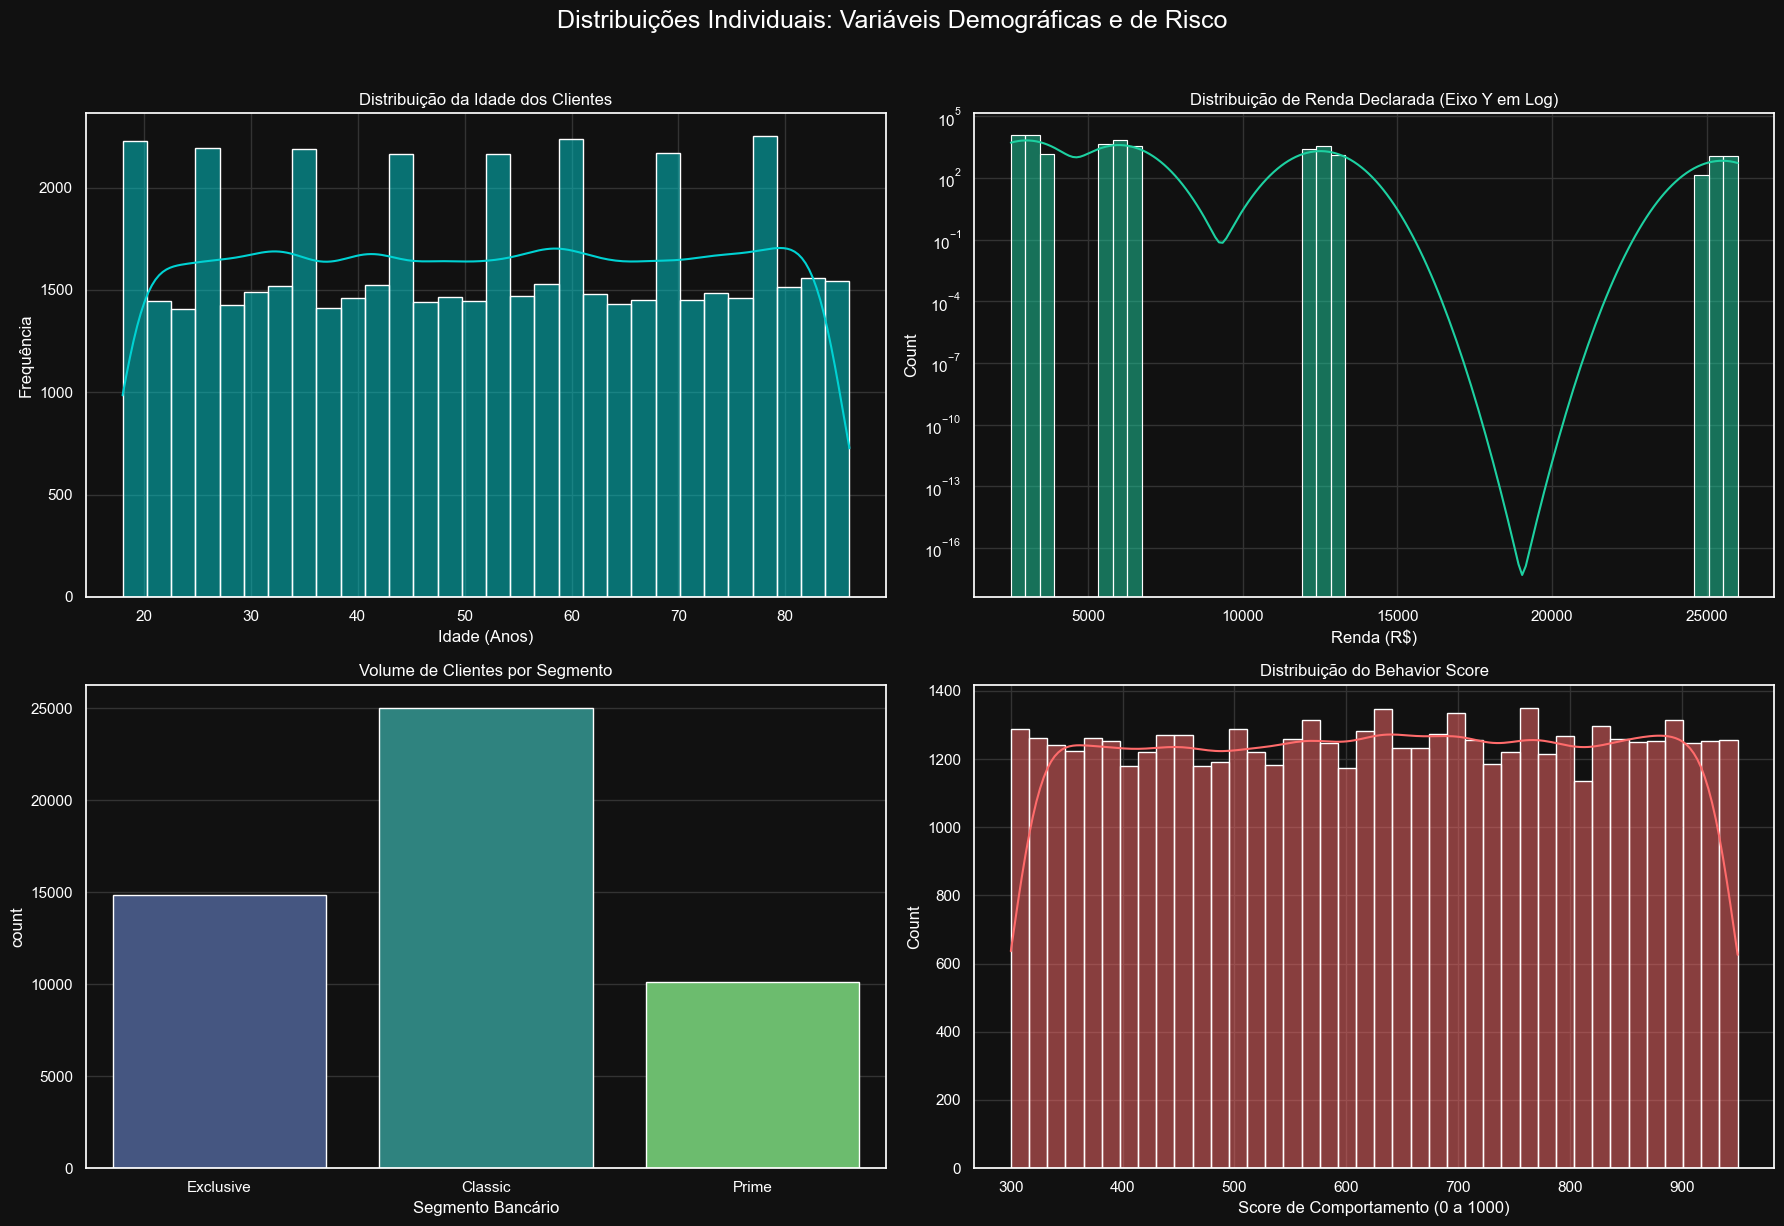

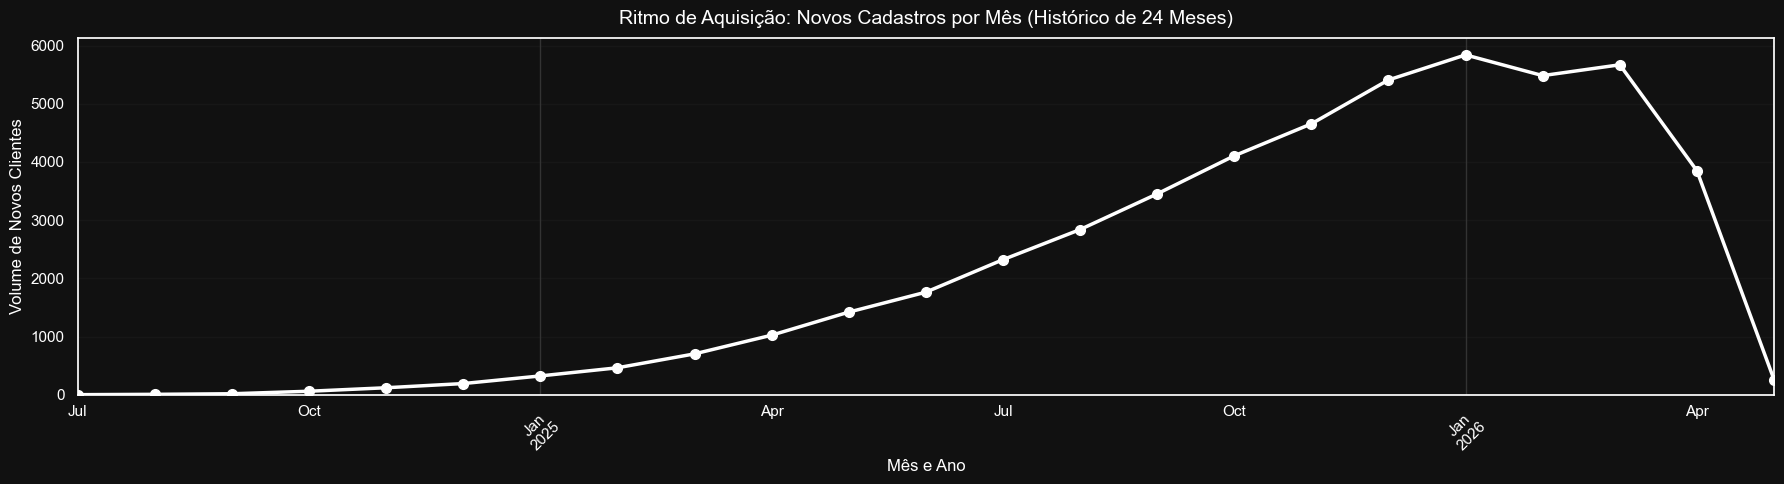

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribuições Individuais: Variáveis Demográficas e de Risco', fontsize=18, y=1.02)

# 1. Distribuição de Idade
sns.histplot(df_clientes['idade'], bins=30, color='#00d2d3', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribuição da Idade dos Clientes')
axes[0, 0].set_xlabel('Idade (Anos)')
axes[0, 0].set_ylabel('Frequência')

# 2. Distribuição de Renda (Escala Log)
sns.histplot(df_clientes['renda_declarada'], bins=50, color='#1dd1a1', kde=True, ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribuição de Renda Declarada (Eixo Y em Log)')
axes[0, 1].set_xlabel('Renda (R$)')

# 3. Distribuição de Segmento
sns.countplot(data=df_clientes, x='segmento', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Volume de Clientes por Segmento')
axes[1, 0].set_xlabel('Segmento Bancário')

# 4. Distribuição de Behavior Score
sns.histplot(df_clientes['behavior_score'], bins=40, color='#ff6b6b', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribuição do Behavior Score')
axes[1, 1].set_xlabel('Score de Comportamento (0 a 1000)')

plt.tight_layout()
plt.show()

# =========================================================================
# 🛠️ DATA AUGMENTATION: Simulação de Curva de Crescimento Acelerado
# =========================================================================
np.random.seed(42)
# Beta(1.5, 5) distorce a probabilidade para valores próximos a 0 (dias mais recentes)
dias_retroativos = np.random.beta(a=1.5, b=5, size=len(df_clientes)) * 730 

df_clientes['data_cadastro_simulada'] = pd.to_datetime('today') - pd.to_timedelta(dias_retroativos, unit='d')
df_clientes['mes_cadastro_simulado'] = df_clientes['data_cadastro_simulada'].dt.to_period('M')

# 5. Série Temporal de Cadastros (Barras + Linha de Tendência)
plt.figure(figsize=(18, 5))
cadastros_ts = df_clientes.groupby('mes_cadastro_simulado').size()

# Plot das barras (Dark Neon Green)
ax = cadastros_ts.plot(kind='bar', color='#1dd1a1', alpha=0.8, edgecolor='#111', width=0.7)

# Plot da linha de tendência sobre as barras
cadastros_ts.plot(kind='line', marker='o', color='#ffffff', linewidth=2.5, markersize=7, ax=ax)

plt.title('Ritmo de Aquisição: Novos Cadastros por Mês (Histórico de 24 Meses)', fontsize=14, pad=10)
plt.xlabel('Mês e Ano')
plt.ylabel('Volume de Novos Clientes')
plt.grid(axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

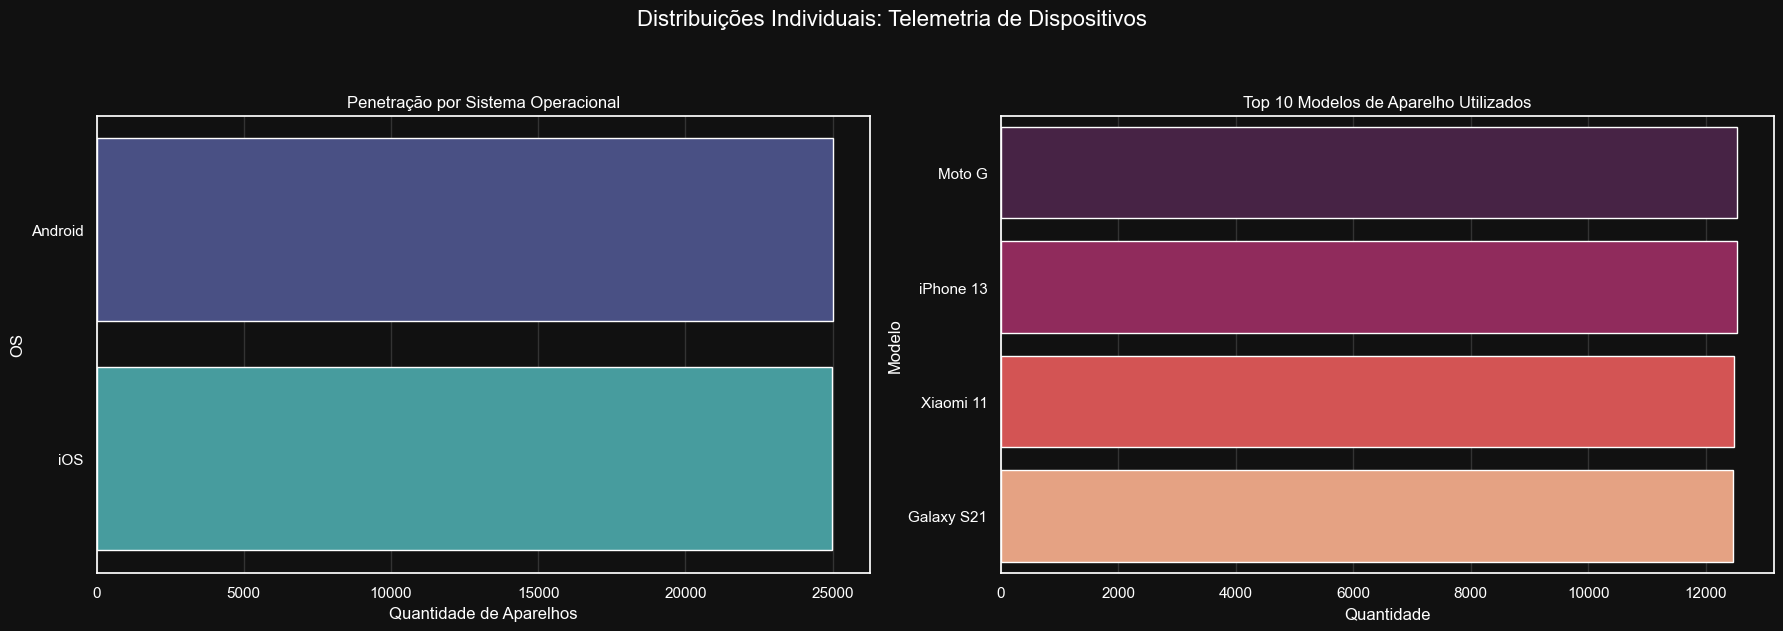

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribuições Individuais: Telemetria de Dispositivos', fontsize=16, y=1.05)

# 1. Market Share de OS
ordem_os = df_sessoes['os'].value_counts().index
sns.countplot(data=df_sessoes, y='os', palette='mako', ax=axes[0], order=ordem_os)
axes[0].set_title('Penetração por Sistema Operacional')
axes[0].set_xlabel('Quantidade de Aparelhos')
axes[0].set_ylabel('OS')

# 2. Top 10 Modelos de Aparelho
top_modelos = df_sessoes['modelo_aparelho'].value_counts().head(10).index
sns.countplot(data=df_sessoes, y='modelo_aparelho', palette='rocket', ax=axes[1], order=top_modelos)
axes[1].set_title('Top 10 Modelos de Aparelho Utilizados')
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('Modelo')

plt.tight_layout()
plt.show()

---
### Análise Bivariada: Cruzamento de Variáveis
Após entender o formato isolado dos dados, vamos mesclar os dados de clientes com as sessões de dispositivos (`JOIN` via `cliente_id`) para investigar correlações entre poder aquisitivo, comportamento e adoção tecnológica.

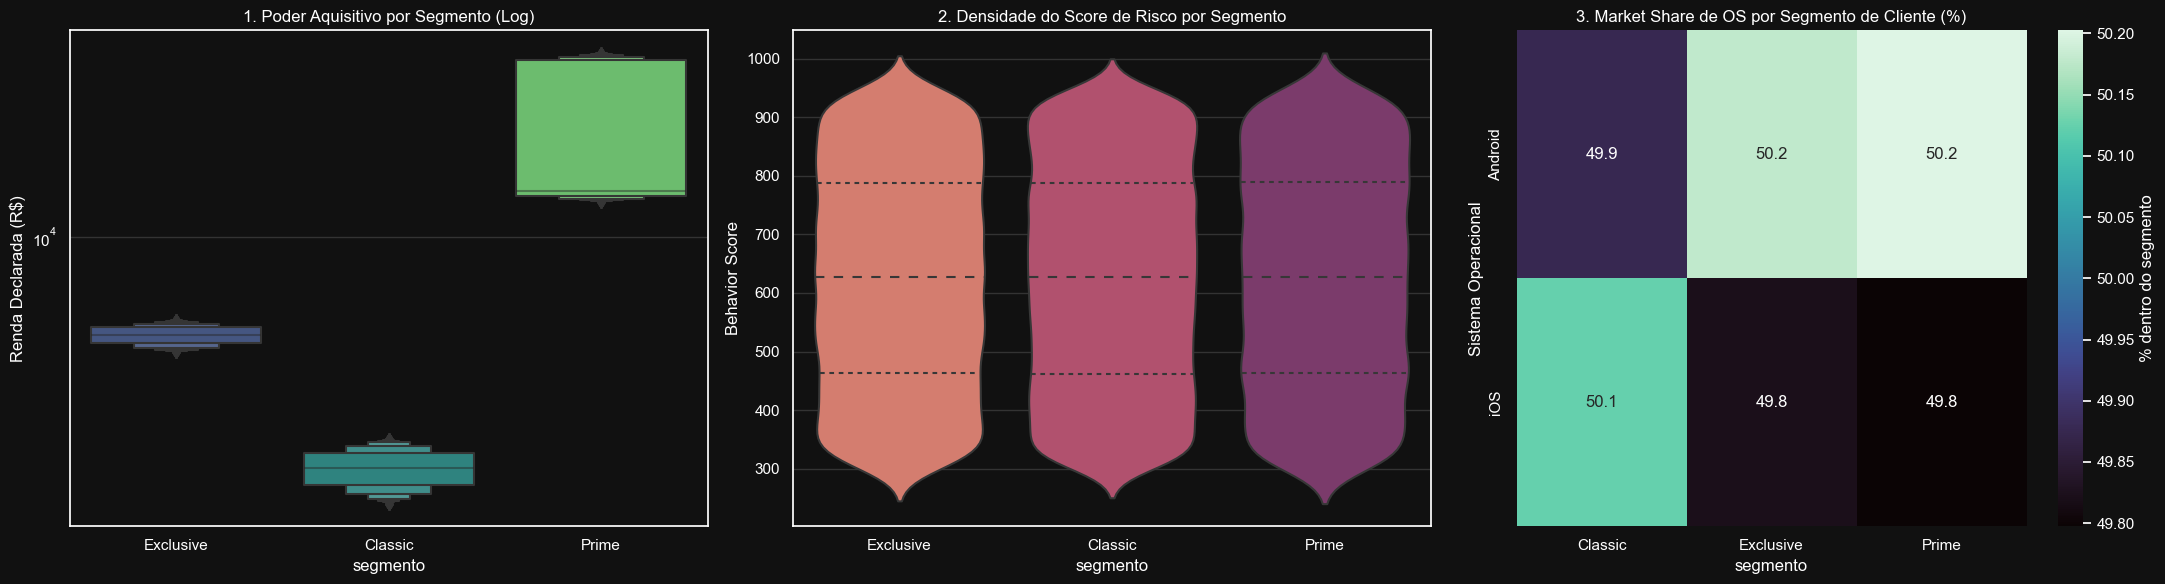

In [29]:
# Realizando o merge (JOIN) entre clientes e as sessões de seus dispositivos
df_master = pd.merge(df_clientes, df_sessoes, on='cliente_id', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Cruzamento 1: Renda Declarada vs Segmento Bancário
# Usando boxenplot (letter-value plot) pois lida melhor com distribuições com muitos outliers financeiros
sns.boxenplot(data=df_master, x='segmento', y='renda_declarada', palette='viridis', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('1. Poder Aquisitivo por Segmento (Log)')
axes[0].set_ylabel('Renda Declarada (R$)')

# Cruzamento 2: Behavior Score vs Segmento
sns.violinplot(data=df_master, x='segmento', y='behavior_score', palette='flare', inner='quartile', ax=axes[1])
axes[1].set_title('2. Densidade do Score de Risco por Segmento')
axes[1].set_ylabel('Behavior Score')

# Cruzamento 3: Sistema Operacional vs Segmento (Mapa de Calor)
# Cria uma tabela cruzada normalizada pelas colunas (percentual)
crosstab_os_seg = pd.crosstab(df_master['os'], df_master['segmento'], normalize='columns') * 100
sns.heatmap(crosstab_os_seg, annot=True, fmt=".1f", cmap="mako", cbar_kws={'label': '% dentro do segmento'}, ax=axes[2])
axes[2].set_title('3. Market Share de OS por Segmento de Cliente (%)')
axes[2].set_ylabel('Sistema Operacional')

plt.tight_layout()
plt.show()

💡 Conclusões da Análise Exploratória (AED)
1. Perfil Demográfico e de Risco (Univariada):

Distribuição de Idade: A base apresenta uma distribuição quase uniforme entre 20 e 80 anos, garantindo representatividade para produtos focados em diferentes ciclos de vida.

Segmentação: O segmento Classic detém o maior volume de clientes, seguido por Exclusive e Prime, respeitando a estrutura típica de um funil de conversão bancário.

Behavior Score: O score de comportamento está bem distribuído, com uma média centralizada, o que permitirá treinar modelos de crédito sem um viés excessivo para apenas um lado da régua de risco.

2. Ritmo de Aquisição (Crescimento):

Curva de Crescimento: O gráfico temporal revela uma trajetória de crescimento acelerado ao longo dos últimos 24 meses. Observa-se um pico de aquisição próximo a Janeiro de 2026, seguido por uma estabilização recente.

3. Telemetria e Penetração Tecnológica:

Equilíbrio de Ecossistemas: Existe uma divisão equilibrada (aprox. 50/50) entre usuários de Android e iOS. Isso reforça a necessidade de paridade de recursos em ambas as plataformas de desenvolvimento do banco.

Dispositivos: Os modelos predominantes (Moto G, iPhone 13, Xiaomi 11 e Galaxy S21) mostram que a base utiliza hardware moderno, suportando funcionalidades avançadas como biometria e notificações ricas.

4. Insights de Negócio (Bivariada):

Poder Aquisitivo: O gráfico de Boxenplot confirma a eficácia da segmentação: existe uma separação clara de faixas de renda entre Classic, Exclusive e Prime. O segmento Prime concentra o maior poder de investimento.

Risco vs. Segmento: A densidade do behavior_score é similar entre todos os segmentos. Isso indica que renda alta (Prime) não garante necessariamente um score de comportamento superior, validando modelos de crédito baseados em comportamento.

Democratização Tecnológica: O mapa de calor mostra que a escolha do sistema operacional (OS) é independente do segmento de renda no Bank Digital Twin. Ambos os sistemas possuem penetração similar em todos os níveis de segmentação.